In [31]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import pandas as pd
from pathlib import Path
import yaml
import spacy

def load_config(path):
    """
    Load event config file and data.

    Returns: Config `cfg` and DataFrame `df`.
    """
    config_file = path
    cfg = yaml.safe_load(Path(config_file).read_text(encoding='utf-8')).get('event', {})

    # Normalize keywords
    nlp = spacy.load("en_core_web_lg")
    doc = nlp(" ".join(cfg["keywords"]))
    cfg['keywords'] = [t.lemma_ for t in doc]

    # Check if cleaned file exists
    cleaned_path = Path(cfg['input_file'].replace('/raw/', '/clean/'))
    if cleaned_path.exists():
        print(f"Reading cleaned file: {cleaned_path}")
        cfg['cleaned_file'] = cleaned_path
        df = pd.read_csv(cleaned_path)
    else: 
        print(f"Reading raw file: {cfg['input_file']}")
        df = pd.read_csv(cfg['input_file'])

    return cfg, df

In [33]:
### Timing decorator
import time

def timing(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper


In [34]:
from preprocessing.normalize_text import normalize_text_series

def normalize_texts(df, batch_size=50, n_process=10):
    """
    Create clean text columns for 'title', 'text' and 'first_para'.
    """

    if 'title' in df:
        df['title_clean'] = normalize_text_series(df['title'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'text' in df:
        df['text_clean'] = normalize_text_series(df['text'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'first_para' in df:
        df['first_para_clean'] = normalize_text_series(df['first_para'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    
    return df

In [35]:
from preprocessing.tfidf_dedupe import dedupe_tfidf_cosine

@timing
def dedupe_texts(df, text_col):
    """
    Dedupe entries in `df` with nearly identical values in `text_col`. Keeps the longest text by default.
    """
    threshold = 0.9
    min_df = 1  # min doc frequency
    ngram_min = 1
    ngram_max = 2
    max_features=None
    prefer_longer = True
    block_by_length = True  # compare only to similar length documents
    return_groups = True

    deduped_df, dedupe_report = dedupe_tfidf_cosine(
        df,
        text_col=text_col,
        threshold=threshold,
        min_df=min_df,
        ngram_min=ngram_min,
        ngram_max=ngram_max,
        max_features=max_features,
        prefer_longer=prefer_longer,
        block_by_length=block_by_length,
        return_groups=return_groups,
    )

    return deduped_df, dedupe_report

In [ ]:
config_file = Path("config/boogaloo.yaml")
cfg, df = load_config(config_file)

root_dir = Path(".").absolute()

Reading cleaned file: data/event_data/clean/2020_boogaloo_CA.csv


In [37]:
# Prepare output dir

save_output = True  # Save output files

output_dir = root_dir.joinpath(f"output/{config_file.stem}")
print(f"Output dir: {output_dir}")

if save_output:  # Make output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

report = dict()
# report['cfg'] = cfg


Output dir: /data/jupyter/event_dynamics/HSMS_LUGOS/output/boogaloo


In [38]:

# If we did not find a cleaned file, cleanup text
if not 'cleaned_file' in cfg:
    # Normalize text columns
    df = normalize_texts(df)
    # Dedupe DF
    df, report_text = dedupe_texts(df, text_col='text_clean')
    df, report_title = dedupe_texts(df, text_col='title_clean')
    df, report_para = dedupe_texts(df, text_col='first_para')

    print(f"Documents after deduping: {len(df)}")

report["docs_clean"] = len(df)

In [39]:
# Make datetime indices and filter dates
df.index = pd.DatetimeIndex(pd.to_datetime(df["date"], format="%Y%m%d"))
df = df.sort_index()
df = df[cfg['start_date']: cfg['end_date']]

# Drop datetime indices
df = df.reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df = df.sort_values("date")
dates = df["date"]


In [40]:
# Normalize time (t=-7 to t=+30), aggregate per day
from typing import Tuple
from datetime import datetime

def normalize_time(df: pd.DataFrame,
                   date_col: str = 'date',
                   onset_date: datetime = None):
    """
    Normalize date column and convert it to discrete time indices.
    """
    if onset_date is None:
        print(f"Must inform onset_date!")
        exit(1)
    onset_date = pd.to_datetime(onset_date)
    
    norm_time = (df[date_col] - onset_date).dt.days
    return norm_time

df['norm_date'] = normalize_time(df, 'date', cfg['onset_date'])
df['norm_date']

0        -7
267      -7
266      -7
265      -7
264      -7
         ..
14422    38
14423    38
14424    38
14412    38
14571    38
Name: norm_date, Length: 14572, dtype: int64

In [41]:
texts = (df['title_clean'].fillna("") + ". " + df['first_para_clean'].fillna(""))  # .tolist()
# texts = (df['title_clean'].fillna(""))  # .tolist()



In [42]:
### Count documents containing seed keywords

import re
from collections import Counter

# Get seed word list from config and normalize to match cleaned texts
seed_words_raw = cfg.get('keywords', [])
# Normalize: lowercase, strip non-alpha (same style as clean_text_regex)
seed_words = []
for w in seed_words_raw:
    w_norm = re.sub(r'[^a-z\s]', '', str(w).lower()).strip()
    if w_norm:
        seed_words.append(w_norm)

seed_words = sorted(set(seed_words))

# 3) Tokenize each cleaned text into a list of words (whitespace split)
def tokenize_cleaned(s: str):
    # 'texts' are already cleaned (lowercase, non-alpha removed, stopwords removed)
    return s.split()

seed_set = set(seed_words)

doc_seed_hits_detail = []
doc_seed_hits_count = []
doc_seed_hits_unique = []

for s in texts:
    toks = tokenize_cleaned(s)
    # Count only tokens that are seeds
    hits = [t for t in toks if t in seed_set]
    cnt = Counter(hits)
    doc_seed_hits_detail.append(cnt)              # Counter dict per doc
    doc_seed_hits_count.append(sum(cnt.values())) # total matches
    doc_seed_hits_unique.append(len(cnt.keys()))  # unique seeds matched

# Attach to df (aligned by row)
df["seed_hits_count"] = doc_seed_hits_count
df["seed_hits_unique"] = doc_seed_hits_unique
# To store a JSON-friendly form of the dict:
df["seed_hits_detail"] = [dict(c) for c in doc_seed_hits_detail]

print(f"Documents with >= 1 seed hit: {(df['seed_hits_count']>0).sum()}/{len(df)}")

Documents with >= 1 seed hit: 2108/14572


/data/jupyter/event_dynamics/HSMS_LUGOS


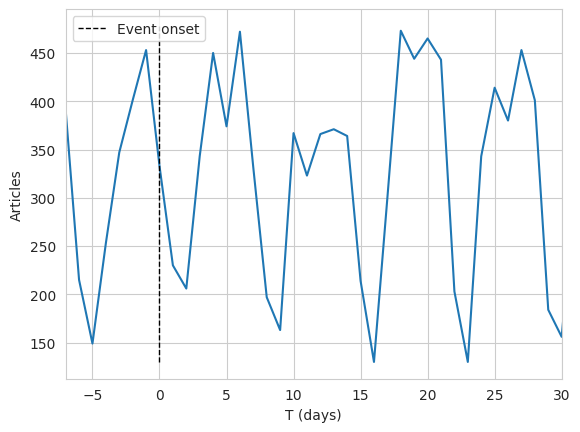

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
# articles_per_day = df.resample('1D', on="date")['GlobalEventID'].count().plot();
articles_per_day = df.groupby('norm_date')['GlobalEventID'].count();

fig = sns.lineplot(data=articles_per_day);
plt.xlabel("T (days)")
plt.ylabel("Articles")
plt.xlim(-7,30)
plt.vlines((0), ymin=min(articles_per_day), ymax=max(articles_per_day+5), linestyles='--', colors='black', linewidth=1, label='Event onset');
plt.legend();


if save_output:
    print(Path(".").absolute())
    plt.savefig(output_dir.joinpath("articles_per_day.pdf"))
    

In [44]:
from sentence_transformers import SentenceTransformer

# load embeddings
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)
embeddings = embedder.encode(texts, batch_size=128, show_progress_bar=True)

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

In [45]:
## Filter only documents with some seed hit


seed_mask = df['seed_hits_count'] >= 2
print(f"Documents in: {seed_mask.sum()} | out: {(1-seed_mask).sum()}")

## Before we drop documents from the dataset, let us find those with high SBERT similarity to seed-hit docs

# Compute the nearest neighbors of each non-seed documents and flip it if the majority is in-topic.
from analysis.topic_modeling import knn_majority_flip

new_mask, details = knn_majority_flip(embeddings, seed_mask)

print(f"Before join: {seed_mask.sum()}. After join: {new_mask.sum()}")

report['docs_after_join'] = int(new_mask.sum())

Documents in: 983 | out: 13589
Before join: 983. After join: 983


In [46]:
# Split dataframes
import numpy as np


df['row_id'] = np.arange(len(df))

df_in = df[new_mask]
# texts_in = texts[new_mask].copy().reset_index(drop=True)
texts_in = texts[new_mask]
embeddings_in = embeddings[new_mask]

df_out = df[~new_mask]
texts_out = texts[~new_mask]
embeddings_out = embeddings[~new_mask]



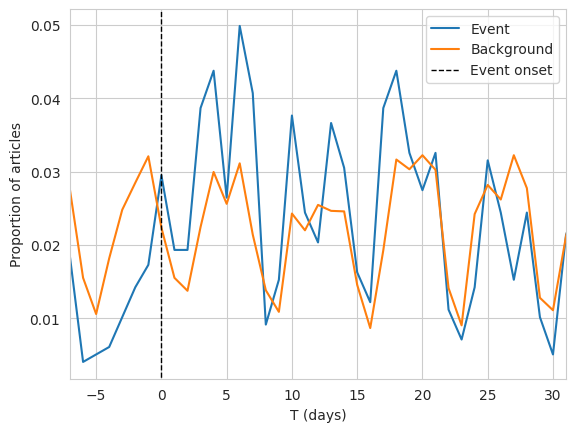

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

articles_per_day_in = df_in['norm_date'].value_counts(normalize=True)
articles_per_day_out = df_out['norm_date'].value_counts(normalize=True)

max_y = max(max(articles_per_day_in), max(articles_per_day_out))

plt.xlim(-7,31)
sns.lineplot(data=articles_per_day_in, label="Event")
sns.lineplot(data=articles_per_day_out, label="Background")
plt.autoscale(False)  # Set autoscale before drawing vertical line
plt.vlines((0), ymin=0, ymax=1, linestyles='--', colors='black', linewidth=1, label='Event onset')
plt.ylabel("Proportion of articles")
plt.xlabel("T (days)")
plt.legend();

if save_output:
    plt.savefig(output_dir.joinpath("event_articles_per_day.pdf"))

In [48]:
from analysis.topic_modeling import init_bertopic_model
import numpy as np

topic_model = init_bertopic_model(cfg['keywords'], seed_multiplier=1.0)
topics, probs = topic_model.fit_transform(texts, embeddings)

topic_info = topic_model.get_topic_info()
display(topic_info.head(15))

df['topic'] = topics


,Topic,Count,Name,Representation,Representative_Docs
0,-1,6362,-1_california_police_new_state,"[california, police, new, state, say, covid, y...",[police violence physical mental health impact...
1,0,4215,0_california_state_say_police,"[california, state, say, police, new, coronavi...",[wrong people fair opportunity californian vot...
2,1,1359,1_california_covid_new_year,"[california, covid, new, year, state, police, ...",[berkeley school district budget shortfall big...
3,2,1211,2_california_say_state_police,"[california, say, state, police, coronavirus, ...",[racism newfoundland labrador let address. wat...
4,3,997,3_california_new_police_covid,"[california, new, police, covid, people, year,...",[los angeles county extend curfew george floyd...
5,4,170,4_taiwan_drip_worksite_international,"[taiwan, drip, worksite, international, screen...",[momma protest unrest rage george floyd killin...
6,5,159,5_internet_seattle_twitter_say,"[internet, seattle, twitter, say, trump, home,...",[regulator approve pg bankruptcy plan despite ...
7,6,99,6_flu_earthquake_air lease_lease corporation,"[flu, earthquake, air lease, lease corporation...",[ex police officer admit dozen rape murder. po...


In [49]:
# # # === Analyze topic coverage of seed hits

# from analysis.topic_modeling import print_topic_coverage_of_seeds

# print_topic_coverage_of_seeds(df, topics, topic_model, cfg['keywords'])


In [50]:
# Reassign outliers
from analysis.topic_modeling import reassign_outliers

reassign_outliers(df, probs, reassign_prob=0.25)



Outliers before reassign: 6362
Outliers after reassign: 3460


In [51]:

topic_info = topic_model.get_topic_info()
display(topic_info.head(20))


,Topic,Count,Name,Representation,Representative_Docs
0,-1,6362,-1_california_police_new_state,"[california, police, new, state, say, covid, y...",[police violence physical mental health impact...
1,0,4215,0_california_state_say_police,"[california, state, say, police, new, coronavi...",[wrong people fair opportunity californian vot...
2,1,1359,1_california_covid_new_year,"[california, covid, new, year, state, police, ...",[berkeley school district budget shortfall big...
3,2,1211,2_california_say_state_police,"[california, say, state, police, coronavirus, ...",[racism newfoundland labrador let address. wat...
4,3,997,3_california_new_police_covid,"[california, new, police, covid, people, year,...",[los angeles county extend curfew george floyd...
5,4,170,4_taiwan_drip_worksite_international,"[taiwan, drip, worksite, international, screen...",[momma protest unrest rage george floyd killin...
6,5,159,5_internet_seattle_twitter_say,"[internet, seattle, twitter, say, trump, home,...",[regulator approve pg bankruptcy plan despite ...
7,6,99,6_flu_earthquake_air lease_lease corporation,"[flu, earthquake, air lease, lease corporation...",[ex police officer admit dozen rape murder. po...


In [52]:
# Temporal dynamics

# topics_over_time = topic_model.topics_over_time(texts, dates, nr_bins=35)  # ~5 weeks
# fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)
# fig

In [53]:

# Show topic hierarchy after merge

# hier_topics = topic_model.hierarchical_topics(texts)
# fig_h = topic_model.visualize_hierarchy(hierarchical_topics=hier_topics)
# fig_h  


In [54]:
# topic_model.visualize_documents(texts, topics=df['topic'], embeddings=embeddings)

In [55]:
# Centroid functions
from numpy.linalg import norm
import numpy as np


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = norm(a), norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / (na * nb))



def geometric_median(X, eps=1e-5, max_iter=200):
    # X: (n, d)
    y = X.mean(axis=0)
    for _ in range(max_iter):
        d = np.linalg.norm(X - y, axis=1)
        # Avoid division by zero
        d = np.where(d < eps, eps, d)
        w = 1.0 / d
        y_new = (w[:, None] * X).sum(axis=0) / w.sum()
        if np.linalg.norm(y_new - y) < eps:
            break
        y = y_new
    return y


def compute_daily_centroids(df, embeddings, centroid_method: str = "mean") -> pd.DataFrame:
    """
    Compute the centroids for each day for a given topic dataframe.

    Args:
        df (pd.DataFrame): input topic dataframe.
        embeddings (np.ndarray[float]) : The document embeddings.
        centroid_method (str) : The centroid calculation method {'mean' or 'median'}.
    Returns:
    """
    ## Compute the centroids for each day

    daily_centroids = []
    groups = df.groupby(df["norm_date"])
    for gdate, gdf in groups:
        pos_idx = gdf["row_id"].to_numpy()  # Get row positions in original df
        # Find local positions for embeddings
        local_idx = df.index.get_indexer(gdf.index)        # positions within df_topic    
        emb_day = embeddings[local_idx]  # Get embeddings for this date
        if emb_day.size == 0:
            continue
        if centroid_method == "mean":
            centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
        elif centroid_method == "median":
            centroid_sbert = geometric_median(emb_day)
        else:
            print(f"Invalid centroid_method: {centroid_method}")
            exit(1)
        daily_centroids.append({
            "date_str": gdate,
            "emb": centroid_sbert,
            "n_docs": len(emb_day)
        })


    # Convert to DataFrame and sort chronologically
    cent_df = pd.DataFrame(daily_centroids)
    # Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
    cent_df["dt"] = cent_df['date_str']
    cent_df = cent_df.sort_values("dt").reset_index(drop=True)

    return cent_df


def smoothen_centroids(cent_df: pd.DataFrame) -> pd.DataFrame:
    #  Exponential Moving Average (EMA) smoothing of centroids (vector EMA)
    use_vol_scale = True

    vol_scale = np.percentile(cent_df["n_docs"], 75)  # robust target volume
    base_alpha = 0.20  # Lower = smoother

    ema = []
    prev = None
    for i, row in cent_df.iterrows():
        c = row["emb"]  # numpy 1D vector
        n = row["n_docs"]
        # Adjust alpha per number of documents on that day / cap at [min_alpha, base_alpha]
        if use_vol_scale:
            adj_alpha = base_alpha * min(1.0, n / vol_scale)
            adj_alpha = max(0.05, adj_alpha)  # avoid freezing on small n
        else:
            adj_alpha = base_alpha

        if prev is None:
            s = c.copy()           # initialize EMA with first day's centroid
        else:
            s = adj_alpha * c + (1.0 - adj_alpha) * prev
        ema.append(s)
        prev = s

    cent_df["centroid_ema"] = ema  # attach smoothed centroid


    # Distance between consecutive smoothed centroids (main stability signal)
    dist_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "centroid_ema"], cent_df.loc[i-1, "centroid_ema"])
        dist_smooth.append(d)
    cent_df["dist_smooth_to_prev_smooth"] = dist_smooth

    # Distance between raw centroid and previous day's smoothed centroid (outlier sensitivity)
    dist_raw_to_prev_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "emb"], cent_df.loc[i-1, "centroid_ema"])
        dist_raw_to_prev_smooth.append(d)
    cent_df["dist_raw_to_prev_smooth"] = dist_raw_to_prev_smooth

    return cent_df

In [56]:
# Find largest topic

topic_info = topic_model.get_topic_info()

# Find the largest topic by size
largest_topic_row = topic_info.loc[topic_info['Count'].idxmax()]
largest_topic_id = largest_topic_row['Topic']
largest_topic_size = largest_topic_row['Count']

print(f"Largest topic ID: {largest_topic_id}, Size: {largest_topic_size}")
print("Top words:", topic_model.get_topic(largest_topic_id))



Largest topic ID: -1, Size: 6362
Top words: [('california', np.float64(0.24962361989083715)), ('police', np.float64(0.23174030437255436)), ('new', np.float64(0.22843010906131667)), ('state', np.float64(0.22611049889974397)), ('say', np.float64(0.22073042675700252)), ('covid', np.float64(0.21797098553143937)), ('year', np.float64(0.2122791293093393)), ('trump', np.float64(0.21197230569774025)), ('coronavirus', np.float64(0.21118785589472383)), ('people', np.float64(0.2043246990723664))]


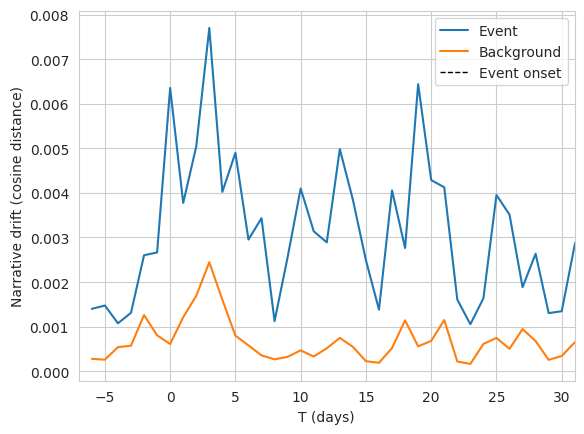

In [57]:
# Retrieve subsets of DataFrame and embeddings
import matplotlib.pyplot as plt

# ## Compute the centroids for each day
cent_df = compute_daily_centroids(df_in, embeddings_in)
cent_df = smoothen_centroids(cent_df)


## Compute non-topic centroids
cent_df_c = compute_daily_centroids(df_out, embeddings_out)
cent_df_c = smoothen_centroids(cent_df_c)


# print(cent_df[["dt", "n_docs", "dist_smooth_to_prev_smooth", "dist_raw_to_prev_smooth"]].head(10))

# print(cent_df_c[["dt", "n_docs", "dist_smooth_to_prev_smooth", "dist_raw_to_prev_smooth"]].head(10))

plt.xlim(-7,31)

y_col = 'dist_smooth_to_prev_smooth'
sns.lineplot(data=cent_df, x='dt', y=y_col, label='Event');
# plt.xticks(rotation=45);


sns.lineplot(data=cent_df_c, x='dt', y=y_col, label='Background')
# plt.xticks(rotation=45);
plt.vlines((0), ymin=0, ymax=max(cent_df[y_col]), linestyles='--', colors='black', linewidth=1, label='Event onset')
plt.legend()
plt.ylabel('Narrative drift (cosine distance)')
plt.xlabel('T (days)');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_drift.pdf"))




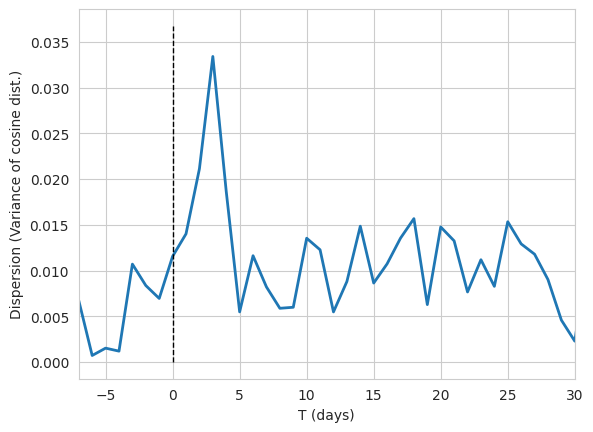

In [58]:
### Plot dispersion

from analysis.dispersion import get_centroid_dispersion_per_day

dispersion = get_centroid_dispersion_per_day(df_in, embeddings_in)
cent_df['dispersion'] = dispersion

sns.lineplot(data=cent_df, x='dt', y='dispersion', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Dispersion (Variance of cosine dist.)")
plt.xlim(-7,30)
plt.vlines((0), ymin=0, ymax=max(dispersion*1.1), linestyles='--', colors='black', linewidth=1, label='Event onset');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_dispersion.pdf"))



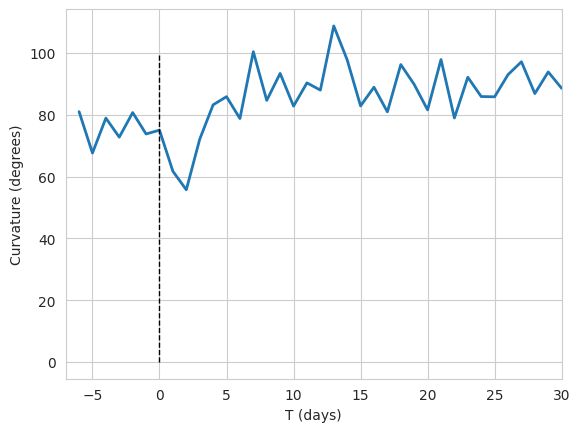

In [59]:
### Get daily curvatures
from analysis.dispersion import compute_curvature

curvatures = compute_curvature(cent_df['centroid_ema'], output_unit='degrees')
cent_df['curvature'] = curvatures

sns.lineplot(data=cent_df, x='dt', y='curvature', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Curvature (degrees)")
plt.xlim(-7,30)
plt.vlines((0), ymin=0, ymax=100, linestyles='--', colors='black', linewidth=1, label='Event onset');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_curvature.pdf"))

In [60]:
### Dump report and daily dataframe
import json

print(report)
if save_output:
    cent_df.to_csv(output_dir.joinpath("daily_event.csv"), index=None)
    cent_df_c.to_csv(output_dir.joinpath("daily_background.csv"), index=None)
    with open(output_dir.joinpath("report.json"), "w") as fout:
        fout.write(json.dumps(report))

    print("Saved all output!")

{'docs_clean': 14804, 'docs_after_join': 983}
Saved all output!
